In [1]:
# Figure 4 chi = 600 and sigma = 300

import numpy as np
import matplotlib.pyplot as plt

from symengine import exp, cos, pi, Abs
from jitcdde import y, t, jitcdde

# Parameters
phi_B     = 0.018
phi_H     = 0.007
epsilon_B = 2000
b         = 500
k         = 5000
a         = 500
tau       = 12
gamma_B   = 0.003
gamma_H   = 0.05
delta_1   = 0.06
delta_2   = 0.06
epsilon_T = 1
gamma_T   = 1/24
chi       = 600
sigma     = 300
theta     = 105
kappa     = 1/9

# Initial conditions
B0 = 5000
H0 = 10000
T0 = 2
V0 = 1
f0 = 1000

# For constant past, q0 is constant on [-tau,0] so I0 = q0*tau
q0 = delta_1 * T0/(a + B0) + delta_2 * V0/(a + B0)
I0 = q0 * tau

# SIMULATION SETUP
STARTTIME = 0
STOPTIME  = 730
DT        = 0.02
eps       = 1e-6

def Phi_numeric(tt):
    return chi + sigma * np.cos(2*np.pi*(tt - theta)/365)

# Helpers
def pos(x):
    # symbolic max(x,0)
    return (x + Abs(x))/2

# States
IDX_B = 0
IDX_H = 1
IDX_T = 2
IDX_V = 3
IDX_f = 4
IDX_I = 5

B = y(IDX_B)
H = y(IDX_H)
T = y(IDX_T)
V = y(IDX_V)
f = y(IDX_f)
I = y(IDX_I)

# delayed states
B_tau = y(IDX_B, t - tau)
T_tau = y(IDX_T, t - tau)
V_tau = y(IDX_V, t - tau)

# Euler-like nonnegativity inside RHS (important with delays)
B_pos     = pos(B)
H_pos     = pos(H)
T_pos     = pos(T)
V_pos     = pos(V)
f_pos     = pos(f)
I_pos     = pos(I)        #optional
B_tau_pos = pos(B_tau)
T_tau_pos = pos(T_tau)
V_tau_pos = pos(V_tau)

# MODEL TERMS
# Survival/egg production
S = (f_pos / (b + f_pos)) * (H_pos / (k + H_pos))

# Infestation / infection
infestation = delta_1 * (B_pos / (a + B_pos)) * T_pos
infection   = delta_2 * (B_pos / (a + B_pos)) * V_pos

# Integral dynamics: I' = q(t) - q(t-τ)
q_now = delta_1 * T_pos/(a + B_pos) + delta_2 * V_pos/(a + B_pos)
q_tau = delta_1 * T_tau_pos/(a + B_tau_pos) + delta_2 * V_tau_pos/(a + B_tau_pos)
dI    = q_now - q_tau

# Maturation survival term
exp_B = exp(-gamma_B * tau - I_pos)

# Seasonal Phi(t)
Phi = chi + sigma * cos(2*pi*(t - theta)/365)

# DDE SYSTEM
dB = epsilon_B * S - infestation - infection - gamma_B * B_pos - kappa * exp_B * B_tau_pos
dH = kappa * exp_B * B_tau_pos - gamma_H * H_pos
dT = epsilon_T * infestation - gamma_T * T_pos
dV = epsilon_T * infection   - gamma_T * V_pos
df = Phi * (H_pos / (k + H_pos)) - phi_B * B_pos - phi_H * H_pos

# EXTRA: Euler-like "projection" so the *state* doesn't drift negative (helps delay history)
lam = 120  # tune 80–150 if needed
dB = dB + lam * (B_pos - B)
dH = dH + lam * (H_pos - H)
dT = dT + lam * (T_pos - T)
dV = dV + lam * (V_pos - V)
df = df + lam * (f_pos - f)
dI = dI + lam * (I_pos - I)

# BUILD SOLVER
DDE = jitcdde([dB, dH, dT, dV, df, dI])

# Constant history for s <= 0
def history(s):
    return [B0, H0, T0, V0, f0, I0]

DDE.past_from_function(history)
DDE.step_on_discontinuities()

# Solver settings: keep max_step ~ DT to mimic Euler stepping near kinks
DDE.set_integration_parameters(atol=1e-8, rtol=1e-6, min_step=1e-12, max_step=DT, first_step=DT)

# INTEGRATE
# avoid backward integration warning
t0 = float(DDE.t)
start = max(STARTTIME + eps, t0)

times = np.arange(start, STOPTIME + DT/2, DT)
times_plot = np.concatenate(([STARTTIME], times))

sol = np.zeros((len(times_plot), 6), dtype=float)
sol[0, :] = np.array([B0, H0, T0, V0, f0, I0], dtype=float)

for i, tt in enumerate(times, start=1):
    sol[i, :] = DDE.integrate(float(tt))

# Unpack
B_values = sol[:, IDX_B]
H_values = sol[:, IDX_H]
T_values = sol[:, IDX_T]
V_values = sol[:, IDX_V]
f_values = sol[:, IDX_f]
I_values = sol[:, IDX_I]

# Phi for plotting
Phi_values = Phi_numeric(times_plot)

# EXPORT RESULTS: RUN 1
times_plot_1 = times_plot.copy()

B_1   = B_values.copy()
H_1   = H_values.copy()
T_1   = T_values.copy()
V_1   = V_values.copy()
f_1   = f_values.copy()

Phi_1 = Phi_values.copy()

Generating, compiling, and loading C code.


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


Using default integration parameters.


In [2]:
# Figure 4 chi = 500 and sigma = 400

import numpy as np
import matplotlib.pyplot as plt

from symengine import exp, cos, pi, Abs
from jitcdde import y, t, jitcdde

# Parameters
phi_B     = 0.018
phi_H     = 0.007
epsilon_B = 2000
b         = 500
k         = 5000
a         = 500
tau       = 12
gamma_B   = 0.003
gamma_H   = 0.05
delta_1   = 0.06
delta_2   = 0.06
epsilon_T = 1
gamma_T   = 1/24
chi       = 500
sigma     = 400
theta     = 105
kappa     = 1/9

# Initial conditions
B0 = 5000
H0 = 10000
T0 = 2
V0 = 1
f0 = 1000

# For constant past, q0 is constant on [-tau,0] so I0 = q0*tau
q0 = delta_1 * T0/(a + B0) + delta_2 * V0/(a + B0)
I0 = q0 * tau

# SIMULATION SETUP
STARTTIME = 0
STOPTIME  = 730
DT        = 0.02
eps       = 1e-6

def Phi_numeric(tt):
    return chi + sigma * np.cos(2*np.pi*(tt - theta)/365)

# Helpers
def pos(x):
    # symbolic max(x,0)
    return (x + Abs(x))/2

# States
IDX_B = 0
IDX_H = 1
IDX_T = 2
IDX_V = 3
IDX_f = 4
IDX_I = 5

B = y(IDX_B)
H = y(IDX_H)
T = y(IDX_T)
V = y(IDX_V)
f = y(IDX_f)
I = y(IDX_I)

# delayed states
B_tau = y(IDX_B, t - tau)
T_tau = y(IDX_T, t - tau)
V_tau = y(IDX_V, t - tau)

# Euler-like nonnegativity inside RHS (important with delays)
B_pos     = pos(B)
H_pos     = pos(H)
T_pos     = pos(T)
V_pos     = pos(V)
f_pos     = pos(f)
I_pos     = pos(I)        
B_tau_pos = pos(B_tau)
T_tau_pos = pos(T_tau)
V_tau_pos = pos(V_tau)

# MODEL TERMS 
# Survival/egg production
S = (f_pos / (b + f_pos)) * (H_pos / (k + H_pos))

# Infestation / infection
infestation = delta_1 * (B_pos / (a + B_pos)) * T_pos
infection   = delta_2 * (B_pos / (a + B_pos)) * V_pos

# Integral dynamics: I' = q(t) - q(t-τ)
q_now = delta_1 * T_pos/(a + B_pos) + delta_2 * V_pos/(a + B_pos)
q_tau = delta_1 * T_tau_pos/(a + B_tau_pos) + delta_2 * V_tau_pos/(a + B_tau_pos)
dI    = q_now - q_tau

# Maturation survival term
exp_B = exp(-gamma_B * tau - I_pos)

# Seasonal Phi(t)
Phi = chi + sigma * cos(2*pi*(t - theta)/365)

# DDE SYSTEM 
dB = epsilon_B * S - infestation - infection - gamma_B * B_pos - kappa * exp_B * B_tau_pos
dH = kappa * exp_B * B_tau_pos - gamma_H * H_pos
dT = epsilon_T * infestation - gamma_T * T_pos
dV = epsilon_T * infection   - gamma_T * V_pos
df = Phi * (H_pos / (k + H_pos)) - phi_B * B_pos - phi_H * H_pos

# EXTRA: Euler-like "projection" 
lam = 120  # tune 80–150 if needed
dB = dB + lam * (B_pos - B)
dH = dH + lam * (H_pos - H)
dT = dT + lam * (T_pos - T)
dV = dV + lam * (V_pos - V)
df = df + lam * (f_pos - f)
dI = dI + lam * (I_pos - I)

# BUILD SOLVER
DDE = jitcdde([dB, dH, dT, dV, df, dI])

# Constant history for s <= 0
def history(s):
    return [B0, H0, T0, V0, f0, I0]

DDE.past_from_function(history)
DDE.step_on_discontinuities()

# Solver settings: keep max_step ~ DT to mimic Euler stepping near kinks
DDE.set_integration_parameters(atol=1e-8, rtol=1e-6, min_step=1e-12, max_step=DT, first_step=DT)

# INTEGRATE
# avoid backward integration warning
t0 = float(DDE.t)
start = max(STARTTIME + eps, t0)

times = np.arange(start, STOPTIME + DT/2, DT)
times_plot = np.concatenate(([STARTTIME], times))

sol = np.zeros((len(times_plot), 6), dtype=float)
sol[0, :] = np.array([B0, H0, T0, V0, f0, I0], dtype=float)

for i, tt in enumerate(times, start=1):
    sol[i, :] = DDE.integrate(float(tt))

# Unpack
B_values = sol[:, IDX_B]
H_values = sol[:, IDX_H]
T_values = sol[:, IDX_T]
V_values = sol[:, IDX_V]
f_values = sol[:, IDX_f]
I_values = sol[:, IDX_I]

# Phi for plotting
Phi_values = Phi_numeric(times_plot)

# EXPORT RESULTS: RUN 2
times_plot_2 = times_plot.copy()

B_2   = B_values.copy()
H_2   = H_values.copy()
T_2   = T_values.copy()
V_2   = V_values.copy()
f_2   = f_values.copy()
Phi_2 = Phi_values.copy()

B_2 = np.maximum(B_2, 0)
H_2 = np.maximum(H_2, 0)
T_2 = np.maximum(T_2, 0)
V_2 = np.maximum(V_2, 0)
f_2 = np.maximum(f_2, 0)


Generating, compiling, and loading C code.


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


Using default integration parameters.


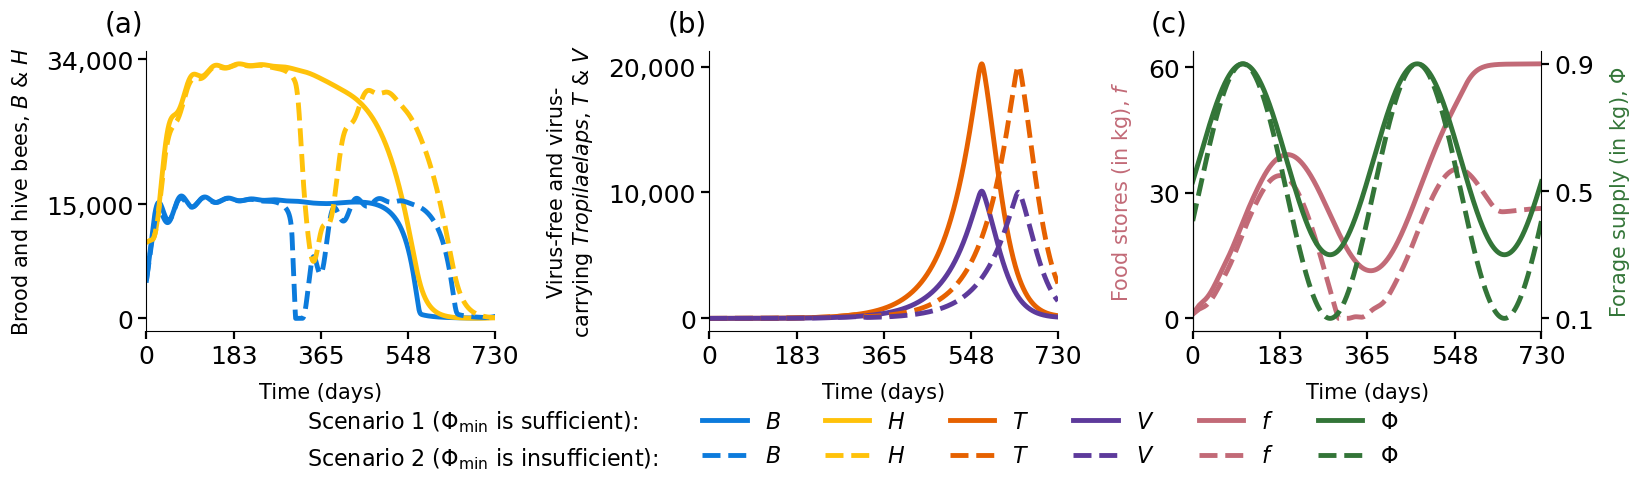

In [3]:
# Figure 4. COMBINED PLOTS: RUN 1 vs RUN 2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

B_color   = (12/255, 123/255, 220/255)
H_color   = (255/255, 194/255, 10/255)
T_color   = (230/255, 97/255, 0/255)
V_color   = (93/255, 58/255, 155/255)
f_color   = (194/255, 106/255, 119/255)
Phi_color = (51/255, 117/255, 56/255)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,4), sharex=True)

# (a) B and H 
l1, = ax1.plot(times_plot_1, B_1, color=B_color, linewidth=3.5, label='$B$')
l2, = ax1.plot(times_plot_1, H_1, color=H_color, linewidth=3.5, label='$H$')
# run 2 as dashed (same colors)
l1b, = ax1.plot(times_plot_2, B_2, color=B_color, linewidth=3.5, linestyle='--', label='$B$')
l2b, = ax1.plot(times_plot_2, H_2, color=H_color, linewidth=3.5, linestyle='--', label='$H$')

ax1.set_xlabel("Time (days)", color='black', fontsize=15, labelpad=10, ha='center')
ax1.set_ylabel("Brood and hive bees, $B$ & $H$", color='black', fontsize=15, labelpad=10, ha='center')
ax1.tick_params(axis='x', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax1.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax1.set_xlim(STARTTIME, STOPTIME)
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_yticks([34000, 15000, 0])
ax1.set_yticklabels(['34,000', '15,000', '0'])
ax1.set_xticks([0, 183, 365, 548, STOPTIME])
ax1.text(-0.12, 1.15, "(a)", transform=ax1.transAxes, color='black', fontsize=20, va='top', ha='left')

# (b) T and V 
l3, = ax2.plot(times_plot_1, T_1, color=T_color, linewidth=3.5, label='$T$')
l4, = ax2.plot(times_plot_1, V_1, color=V_color, linewidth=3.5, label='$V$')
l3b, = ax2.plot(times_plot_2, T_2, color=T_color, linewidth=3.5, linestyle='--', label='$T$')
l4b, = ax2.plot(times_plot_2, V_2, color=V_color, linewidth=3.5, linestyle='--', label='$V$')

ax2.set_xlabel("Time (days)", color='black', fontsize=15, labelpad=10, ha='center')
ax2.set_ylabel("Virus-free and virus-\ncarrying $Tropilaelaps$, $T$ & $V$",
               color='black', fontsize=15, labelpad=10, ha='center')
ax2.tick_params(axis='x', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax2.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax2.set_xlim(STARTTIME, STOPTIME)
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_yticks([20000, 10000, 0])
ax2.set_yticklabels(['20,000', '10,000', '0'])
ax2.set_xticks([0, 183, 365, 548, STOPTIME])
ax2.text(-0.12, 1.15, "(b)", transform=ax2.transAxes, color='black', fontsize=20, va='top', ha='left')

# (c) f and Phi
l5, = ax3.plot(times_plot_1, f_1, color=f_color, linewidth=3.5, label='$f$')
l5b, = ax3.plot(times_plot_2, f_2, color=f_color, linewidth=3.5, linestyle='--', label='$f$')

ax3.set_xlabel("Time (days)", color='black', fontsize=15, labelpad=10, ha='center')
ax3.set_ylabel("Food stores (in kg), $f$", color=f_color, fontsize=15, labelpad=10, ha='center')
ax3.tick_params(axis='x', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax3.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax3.set_xlim(STARTTIME, STOPTIME)
ax3.grid(False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_yticks([60000, 30000, 0])
ax3.set_yticklabels(['60', '30', '0'])
ax3.set_xticks([0, 183, 365, 548, STOPTIME])

ax3b = ax3.twinx()
l6, = ax3b.plot(times_plot_1, Phi_1, color=Phi_color, linewidth=3.5, label='$\\Phi$')
l6b, = ax3b.plot(times_plot_2, Phi_2, linestyle='--', color=Phi_color, linewidth=3.5, label='$\\Phi$')
ax3b.set_ylabel("Forage supply (in kg), $\\Phi$", color=Phi_color, fontsize=15, labelpad=10, ha='center')
ax3b.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax3b.spines['top'].set_visible(False)
ax3b.set_yticks([900, 500, 100])
ax3b.set_yticklabels(['0.9', '0.5', '0.1'])

ax3.text(-0.12, 1.15, "(c)", transform=ax3.transAxes, color='black', fontsize=20, va='top', ha='left')

txt_sufficient = Line2D([], [], linestyle='None')
txt_insufficient = Line2D([], [], linestyle='None')

handles = [txt_sufficient, txt_insufficient, l1, l1b, l2, l2b, l3, l3b, l4, l4b, l5, l5b, l6, l6b]
labels  = [r'Scenario 1 ($\Phi_{\min}$ is sufficient):', r'Scenario 2 ($\Phi_{\min}$ is insufficient):', '$B$', '$B$', '$H$', '$H$', '$T$', '$T$', 
           '$V$', '$V$', '$f$', '$f$', '$\\Phi$', '$\\Phi$']

fig.legend(handles, labels, loc='lower center', ncol=7, fontsize=16, frameon=False, bbox_to_anchor=(0.5, -0.22))
plt.subplots_adjust(bottom=0.18, wspace=0.5)

# manual adjustment of spacing within panels
shift_ab = 0.02  # increase to widen (a)-(b) and narrow (b)-(c)
pos2 = ax2.get_position()
ax2.set_position([pos2.x0 + shift_ab, pos2.y0, pos2.width, pos2.height])
shift_ab = 0.002   # widen (a)-(b)
shift_bc = 0.0  # narrow (b)-(c) further (negative = left)

pos2 = ax2.get_position()
ax2.set_position([pos2.x0 + shift_ab, pos2.y0, pos2.width, pos2.height])

pos3 = ax3.get_position()
ax3.set_position([pos3.x0 + shift_bc, pos3.y0, pos3.width, pos3.height])

# move twin y-axis with ax3
pos3b = ax3b.get_position()
ax3b.set_position([pos3b.x0 + shift_bc, pos3b.y0, pos3b.width, pos3b.height])

plt.savefig("with mites.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# (a) Minimum values in Scenario 2 for t <= 365
mask_365 = times_plot_2 <= 365
times_cut = times_plot_2[mask_365]

if times_cut.size == 0:
    raise ValueError("No data points found for t <= 365.")

state_series = {
    "B": B_2[mask_365],
    "H": H_2[mask_365],
    "f": f_2[mask_365],
    "Φ": Phi_2[mask_365],
}

print("(a)")
print("Scenario 2")
print(f"{'t':>10}{'State variable':>18}{'Minimum':>12}")

for var_name, values in state_series.items():
    idx_min = np.argmin(values)
    t_min = times_cut[idx_min]
    val_min = values[idx_min]
    print(f"{t_min:>10.2f}{var_name:>18}{val_min:>12.2f}")

# Recovery information in Scenario 2
H2_cut = H_2[mask_365]
idx_Hmin = np.argmin(H2_cut)
H2_min = H2_cut[idx_Hmin]
t_Hmin = times_cut[idx_Hmin]

tol = 0.05
idx_start = np.where(times_plot_2 >= t_Hmin)[0][0]

recovery_time = None
recovery_state = None

for i in range(idx_start, len(times_plot_2)):
    B = B_2[i]
    H = H_2[i]

    if B != 0:
        ratio = H / B
        if abs(ratio - 2) <= tol:
            recovery_time = times_plot_2[i]
            recovery_state = (B, H, T_2[i], V_2[i], f_2[i], Phi_2[i], ratio)
            break

if recovery_time is not None:
    B, H, T, V, f, Phi, ratio = recovery_state

    print("\nRecovery detected (Scenario 2)")
    print(f"{'t':>7}{'B':>11}{'H':>11}{'T':>10}{'V':>10}{'f':>11}{'Φ':>10}{'H/B':>7}")
    print(
        f"{recovery_time:>7.2f}"
        f"{B:>11.2f}"
        f"{H:>11.2f}"
        f"{T:>10.2f}"
        f"{V:>10.2f}"
        f"{f:>11.2f}"
        f"{Phi:>10.2f}"
        f"{ratio:>7.2f}"
    )
else:
    print("\nNo recovery (H ≈ 2B) detected after H_min within simulation window.")

idx_T1 = np.argmax(T_1)
idx_T2 = np.argmax(T_2)
idx_V1 = np.argmax(V_1)
idx_V2 = np.argmax(V_2)
print("\n(b)")
print("Scenario 1".ljust(31) + "Scenario 2")
print(f"{'Mites':>5}{'t':>10}{'Maximum':>12}{'t':>10}{'Maximum':>12}")

print(
    f"{'T':>5}"
    f"{times_plot_1[idx_T1]:>10.2f}"
    f"{T_1[idx_T1]:>12.2f}"
    f"{times_plot_2[idx_T2]:>10.2f}"
    f"{T_2[idx_T2]:>12.2f}"
)

print(
    f"{'V':>5}"
    f"{times_plot_1[idx_V1]:>10.2f}"
    f"{V_1[idx_V1]:>12.2f}"
    f"{times_plot_2[idx_V2]:>10.2f}"
    f"{V_2[idx_V2]:>12.2f}"
)

# (c) T, V, and T/V at selected times
target_times = [183, 365, 548, 650, 700]

print("\n(c)")
print("Scenario 1".ljust(37) + "Scenario 2")
print(f"{'t':>5}{'T':>11}{'V':>11}{'T/V':>7}{'T':>11}{'V':>11}{'T/V':>7}")

for tt in target_times:
    idx1 = np.argmin(np.abs(times_plot_1 - tt))
    idx2 = np.argmin(np.abs(times_plot_2 - tt))

    T1 = T_1[idx1]
    V1 = V_1[idx1]
    T2 = T_2[idx2]
    V2 = V_2[idx2]

    ratio1 = T1 / V1 if V1 != 0 else np.nan
    ratio2 = T2 / V2 if V2 != 0 else np.nan

    print(
        f"{tt:>5}"
        f"{T1:>11.2f}"
        f"{V1:>11.2f}"
        f"{ratio1:>7.1f}"
        f"{T2:>11.2f}"
        f"{V2:>11.2f}"
        f"{ratio2:>7.1f}"
    )

(a)
Scenario 2
         t    State variable     Minimum
    312.06                 B        0.00
    349.66                 H     7480.57
    305.22                 f        0.00
    287.50                 Φ      100.00

Recovery detected (Scenario 2)
      t          B          H         T         V          f         Φ    H/B
 454.10   14984.79   29223.69    946.42    473.21   15823.42    885.11   1.95

(b)
Scenario 1                     Scenario 2
Mites         t     Maximum         t     Maximum
    T    570.50    20218.41    647.60    20057.26
    V    570.50    10109.20    647.60    10028.63

(c)
Scenario 1                           Scenario 2
    t          T          V    T/V          T          V    T/V
  183      39.27      19.64    2.0      39.02      19.51    2.0
  365     784.04     392.02    2.0     227.24     113.62    2.0
  548   15479.43    7739.71    2.0    4428.91    2214.46    2.0
  650    3076.87    1538.44    2.0   19886.40    9943.20    2.0
  700     529.59     2